In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import floor
from google.colab import drive

drive.mount('/content/drive', force_remount=True)
file_path = '/content/drive/My Drive/SmartHomeSeptember.xlsx'

# Read Excel file into a DataFrame
data = pd.read_excel(file_path, usecols="A:G")

Mounted at /content/drive


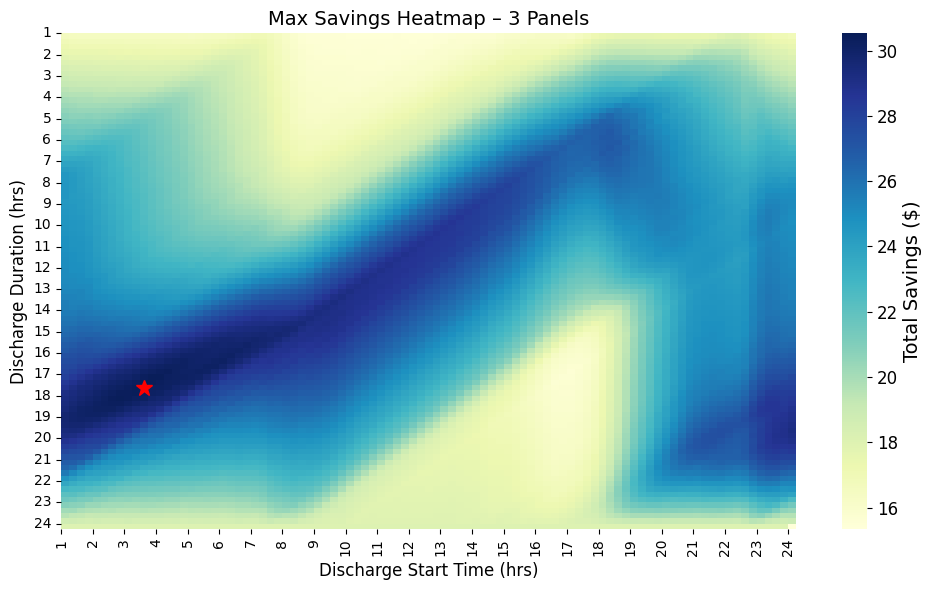

{3: {'start': '03:30',
  'length': '17h 30m',
  'end': '21:00',
  'savings': '$30.53'}}

In [ ]:
# Define function to generate heatmap for optimal allowed discharge window given some number of solar panels and batteries
def BESS_savings_heatmap(filepath, panel_counts=[3], num_batteries=3,
                         soc_min_frac=0.2, soc_max_frac=0.8, initial_soc_frac=1.0,
                         start_range=(1, 24), length_range=(1, 24), resolution_minutes=15,
                         end_date="2016-10-01"):

    # Load and process data from Excel
    df_raw = pd.read_excel(filepath, sheet_name="Sheet1")
    df_raw = df_raw[['Date & Time', 'use [kW]', 'All Solar']].copy()
    df_raw.columns = ['datetime', 'load_kW', 'solar_kW']
    df_raw['datetime'] = pd.to_datetime(df_raw['datetime'])
    df_raw = df_raw[(df_raw['datetime'] >= "2016-09-01") & (df_raw['datetime'] < end_date)]
    df_raw['time_of_day'] = df_raw['datetime'].dt.hour + df_raw['datetime'].dt.minute / 60

    load_kW = df_raw['load_kW'].to_numpy()
    solar_base = df_raw['solar_kW'].to_numpy()
    time_of_day = df_raw['time_of_day'].to_numpy()

    # Define model parameters given function inputs
    eff_charge = 0.93
    eff_discharge = 0.93
    delta_t_hr = 1 / 60
    base_capacity_kWh = 13.5
    capacity_kWh = base_capacity_kWh * num_batteries
    # Define vectors for heatmap x and y axes (start time and length)
    start_values = np.round(np.arange(start_range[0], start_range[1] + 1e-6, resolution_minutes / 60), 4)
    length_values = np.round(np.arange(length_range[0], length_range[1] + 1e-6, resolution_minutes / 60), 4)

    formatted_savings_points = {}

    # Iterate through num_panels vector for multi-case analysis (if needed)
    for num_panels in panel_counts:
        solar_kW = solar_base * num_panels
        net_demand = load_kW - solar_kW
        results = []

        # Use NumPy vectorization for speed (or else code will take hours to run)
        hour_array = np.floor(time_of_day).astype(int)
        price_vector_base = np.where((hour_array >= 14) & (hour_array < 20), 0.2537, 0.0825)
        grid_draw_base = np.clip(net_demand, a_min=0, a_max=None)
        baseline_cost = np.sum(grid_draw_base * price_vector_base * delta_t_hr)

        # Iterate through start and length values for heat map
        for start in start_values:
            for length in length_values:
                end = start + length
                if end <= 24:
                    peak_mask = (time_of_day >= start) & (time_of_day < end)
                else:
                    peak_mask = (time_of_day >= start) | (time_of_day < (end % 24))
                price_vector = np.where(peak_mask, 0.2537, 0.0825)

                soc = initial_soc_frac * capacity_kWh
                soc_min = soc_min_frac * capacity_kWh
                soc_max = soc_max_frac * capacity_kWh
                total_cost = 0.0
                # Iterate through demand over the interval
                for i in range(len(net_demand)):
                    demand = net_demand[i]
                    price = price_vector[i]
                    if demand > 0:
                        # battery discharge
                        if peak_mask[i] and soc > soc_min:
                            discharge_possible = (soc - soc_min) * eff_discharge / delta_t_hr
                            discharge = min(discharge_possible, demand)
                            soc -= (discharge * delta_t_hr) / eff_discharge
                            from_grid = demand - discharge
                        else:
                            from_grid = demand
                    # Else, charge the battery (demand = 0)
                    else:
                        available_charge = (-demand) / (eff_charge * delta_t_hr)
                        charge = min(available_charge, (soc_max - soc) / (eff_charge * delta_t_hr))
                        soc += charge * eff_charge * delta_t_hr
                        from_grid = 0.0

                    total_cost += from_grid * delta_t_hr * price
                # Calculate savings then save in disctionary
                savings = baseline_cost - total_cost
                results.append({
                    'Start': round(start, 4),
                    'Length': round(length, 4),
                    'Savings': savings
                })

        df_result = pd.DataFrame(results)
        heatmap_data = df_result.pivot(index='Length', columns='Start', values='Savings')
        heatmap_data = heatmap_data.sort_index(ascending=True)
        # Pull out max savings and indices
        max_savings = df_result['Savings'].max()
        opt_row = df_result[df_result['Savings'] == max_savings].iloc[0]
        optimal_start = opt_row['Start']
        optimal_length = opt_row['Length']
        optimal_end = (optimal_start + optimal_length) % 24
        # Helper function for displaying the time a little nicer
        def format_time(t):
            h = floor(t)
            m = int(round((t - h) * 60))
            return f"{h:02d}:{m:02d}"
        # Save optimal window as dictionary for each panel count
        formatted_savings_points[num_panels] = {
            "start": format_time(optimal_start),
            "length": f"{floor(optimal_length)}h {int(round((optimal_length % 1) * 60))}m",
            "end": format_time(optimal_end),
            "savings": f"${max_savings:.2f}"
        }

        # Plot Heatmap using Seaborn (since discrete)
        plt.figure(figsize=(10, 6))
        ax = sns.heatmap(heatmap_data, cmap='YlGnBu', cbar_kws={'label': 'Total Savings ($)'})
        ax.set_title(f"Max Savings Heatmap – {panel_counts[0]} Panels", fontsize=14)
        ax.set_xlabel("Discharge Start Time (hrs)", fontsize=12)
        ax.set_ylabel("Discharge Duration (hrs)", fontsize=12)
        cbar = ax.collections[0].colorbar
        cbar.set_label('Total Savings ($)', fontsize=14)

        xticks = [i for i in heatmap_data.columns if i % 1 == 0]
        yticks = [i for i in heatmap_data.index if i % 1 == 0]
        ax.set_xticks([heatmap_data.columns.get_loc(x) for x in xticks])
        ax.set_xticklabels([f"{x:.0f}" for x in xticks])
        ax.set_yticks([heatmap_data.index.get_loc(y) for y in yticks])
        ax.set_yticklabels([f"{y:.0f}" for y in yticks])

        x_idx = heatmap_data.columns.get_loc(optimal_start)
        y_idx = heatmap_data.index.get_loc(optimal_length)
        ax.plot(x_idx + 0.5, y_idx + 0.5, 'r*', markersize=12)

        plt.tight_layout()
        plt.show()

    return formatted_savings_points

# Call Function
formatted_savings_high_capacity = BESS_savings_heatmap(
    filepath=file_path,
    panel_counts=[3],
    num_batteries=1,
    initial_soc_frac=0
)

# display final optimized window
formatted_savings_high_capacity